In [1]:
from transformers import BertModel, BertConfig

/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/home/jupyter/.local/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/jupyter/.local/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
2025-11-06 11:36:59.047202: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import PreTrainedTokenizerFast
import torch
from transformers import BertForMaskedLM, DataCollatorForLanguageModeling
from torch.utils.data import Dataset
from torch.utils.data import DataLoader, random_split
from transformers import DataCollatorForLanguageModeling
from sklearn.model_selection import train_test_split
import os

In [3]:
import lightning as L
import random
def set_random_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)


set_random_seed(42)
L.seed_everything(42)

Seed set to 42


42

In [4]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [31]:
path_dir_models = '/home/jupyter/datasphere/project/Classification/Classification/'

model_n_to_save = '2'

epochs = 20
epochs_frozen = 20
learning_rate = 0.01
learning_rate_frozen = 0.01


for dir in ['transfer learning plots','after learning plots']:
  dir_to_create_path = path_dir_models + model_n_to_save + '/' + dir
  os.makedirs(dir_to_create_path, exist_ok=True)

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import confusion_matrix as sk_cm

def plot_r2_function(y_true, preds, dir_to_save=None):
    r2 = r2_score(y_true, preds)
    fig = plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true, y=preds, alpha=0.6)
    plt.plot([min(y_true), max(y_true)],
             [min(y_true), max(y_true)],
             color='red', linestyle='--', linewidth=1)
    plt.title(f"Scatter plot: True vs Predicted values\n$R^2$ = {r2:.3f}", fontsize=14)
    plt.xlabel("True values", fontsize=12)
    plt.ylabel("Predicted values", fontsize=12)
    plt.grid(True, alpha=0.3)
    if dir_to_save is not None:
        plt.savefig(dir_to_save, dpi=300, bbox_inches='tight')
    plt.show()

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    return {"rmse": np.sqrt(mean_squared_error(labels, predictions))}

def plot_preds_vs_true_histplots(preds, y_true, preds_label="Predictions", true_label="True values", dir_to_save=None):
    sns.set_style("ticks")
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    xlabel = "Values"
    ylabel = "Counts"

    sns.histplot(preds, kde=True, color="blue", label=preds_label, alpha=0.6, ax=axes[0])
    axes[0].set_title("Distribution Predicted values", fontsize=14)
    axes[0].set_xlabel(xlabel, fontsize=12)
    axes[0].set_ylabel(ylabel, fontsize=12)
    axes[0].legend(fontsize=12)

    sns.histplot(preds, kde=True, color="blue", label=preds_label, alpha=0.5, ax=axes[1])
    sns.histplot(y_true, kde=True, color="red", label=true_label, alpha=0.5,  ax=axes[1])
    axes[1].set_title("True vs Predicted values distribution", fontsize=14)
    axes[1].set_xlabel(xlabel, fontsize=12)
    axes[1].set_ylabel(ylabel, fontsize=12)
    axes[1].legend(fontsize=12)

    sns.histplot(y_true, kde=True, color="red", label=true_label, alpha=0.6, ax=axes[2])
    axes[2].set_title("Distribution True values", fontsize=14)
    axes[2].set_xlabel(xlabel, fontsize=12)
    axes[2].set_ylabel(ylabel, fontsize=12)
    axes[2].legend(fontsize=12)

    plt.tight_layout()

    if dir_to_save is not None:
        plt.savefig(dir_to_save, dpi=300, bbox_inches='tight')
    plt.show()
    
def plot_confusion_matrix(cm):
    """Визуализация матрицы ошибок"""
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title('Confusion Matrix')
    return fig

In [7]:
checkpoint_path = '/home/jupyter/datasphere/project/BERT project/Models BERT/1/logs/1/version_12/checkpoints/best.ckpt'

In [8]:
from transformers import BertConfig

config = BertConfig(
    vocab_size=620,  # Должен совпадать с размером словаря
    hidden_size=768,
    num_hidden_layers=4, #4-6 слоев
    num_attention_heads=4, #4-6 слоев
    intermediate_size=3072,
    max_position_embeddings=551,
)

In [9]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from transformers import BertForMaskedLM, get_cosine_schedule_with_warmup
from torchmetrics import MeanMetric, Accuracy
import math

class Pipeline(L.LightningModule):
    def __init__(
        self,
        model,
        exp_name="baseline",
        optimizer_class=AdamW,
        optimizer_kwargs={"lr": 1e-4, "weight_decay": 0.01},
        warmup_steps=1000,
        total_steps=None,
    ) -> None:
        super().__init__()
        self.model = model
        self.optimizer_class = optimizer_class
        self.optimizer_kwargs = optimizer_kwargs
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        
        self.save_hyperparameters(ignore=['model'])
        
        self.train_loss = MeanMetric()
        self.val_loss = MeanMetric()
        self.test_loss = MeanMetric()
        
        # Точность предсказания масок
        vocab_size = model.config.vocab_size  # Получаем размер словаря из модели
        self.train_accuracy = Accuracy(task="multiclass", num_classes=vocab_size)
        self.val_accuracy = Accuracy(task="multiclass", num_classes=vocab_size)
        self.test_accuracy = Accuracy(task="multiclass", num_classes=vocab_size)
        
        # Для расчета перплексии на каждом шаге
        self.train_perplexity = MeanMetric()
        self.val_perplexity = MeanMetric()
        self.test_perplexity = MeanMetric()

    def configure_optimizers(self):
            optimizer = self.optimizer_class(
                self.model.parameters(), **self.optimizer_kwargs
            )

            # Если total_steps не задан, вычисляем автоматически
            if self.total_steps is None and self.trainer is not None:
                self.total_steps = self.trainer.estimated_stepping_batches

            if self.total_steps:
                scheduler = get_cosine_schedule_with_warmup(
                    optimizer,
                    num_warmup_steps=self.warmup_steps,
                    num_training_steps=self.total_steps,
                    num_cycles=0.5  # Для cosine annealing
                )

                return {
                    "optimizer": optimizer,
                    "lr_scheduler": {
                        "scheduler": scheduler,
                        "interval": "step",
                        "frequency": 1,
                    },
                }
            else:
                return optimizer

    def training_step(self, batch, batch_idx):
            outputs = self.model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            # Вычисляем accuracy для масок
            masked_positions = batch['labels'] != -100
            if masked_positions.any():
                mask_predictions = logits[masked_positions].argmax(dim=-1)
                mask_labels = batch['labels'][masked_positions]
                accuracy = self.train_accuracy(mask_predictions, mask_labels)
                self.log('train_accuracy', accuracy, on_step=True, on_epoch=True, prog_bar=True)

            # Вычисляем перплексию для этого батча
            perplexity = torch.exp(loss)
            self.train_perplexity(perplexity)
            self.log('train_perplexity_step', perplexity, on_step=True, on_epoch=False, prog_bar=False)

            self.train_loss(loss)
            self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)

            if self.trainer and self.trainer.optimizers:
                self.log('learning_rate', self.trainer.optimizers[0].param_groups[0]['lr'], on_step=True)

            return loss

    def validation_step(self, batch, batch_idx):
        outputs = self.model(**batch)
        loss = outputs.loss
        logits = outputs.logits

        # Accuracy для валидации
        masked_positions = batch['labels'] != -100
        if masked_positions.any():
            mask_predictions = logits[masked_positions].argmax(dim=-1)
            mask_labels = batch['labels'][masked_positions]
            accuracy = self.val_accuracy(mask_predictions, mask_labels)
            self.log('val_accuracy', accuracy, on_step=False, on_epoch=True, prog_bar=True)

        # Перплексия для валидации
        perplexity = torch.exp(loss)
        self.val_perplexity(perplexity)
        self.log('val_perplexity_step', perplexity, on_step=True, on_epoch=False, prog_bar=False)
        
        self.val_loss(loss)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)

        return loss

    def test_step(self, batch, batch_idx):
        outputs = self.model(**batch)
        loss = outputs.loss
        logits = outputs.logits

        # Accuracy для теста
        masked_positions = batch['labels'] != -100
        if masked_positions.any():
            mask_predictions = logits[masked_positions].argmax(dim=-1)
            mask_labels = batch['labels'][masked_positions]
            accuracy = self.test_accuracy(mask_predictions, mask_labels)
            self.log('test_accuracy', accuracy, on_step=False, on_epoch=True)

        # Перплексия для теста
        perplexity = torch.exp(loss)
        self.test_perplexity(perplexity)
        
        self.test_loss(loss)
        self.log('test_loss', loss, on_step=False, on_epoch=True)

        return loss

    def on_train_epoch_end(self):
        # Вычисляем среднюю перплексию за эпоху
        train_perplexity_epoch = self.train_perplexity.compute()
        val_perplexity_epoch = self.val_perplexity.compute()
        
        # Также вычисляем перплексию из среднего loss (альтернативный расчет)
        train_loss_epoch = self.train_loss.compute()
        val_loss_epoch = self.val_loss.compute()
        train_perplexity_from_loss = torch.exp(train_loss_epoch)
        val_perplexity_from_loss = torch.exp(val_loss_epoch)

        # Логируем оба варианта
        self.log('train_perplexity_epoch', train_perplexity_epoch, on_epoch=True, prog_bar=True)
        self.log('val_perplexity_epoch', val_perplexity_epoch, on_epoch=True, prog_bar=True)
        self.log('train_perplexity_from_loss', train_perplexity_from_loss, on_epoch=True)
        self.log('val_perplexity_from_loss', val_perplexity_from_loss, on_epoch=True)

        # Сбрасываем метрики
        self.train_loss.reset()
        self.val_loss.reset()
        self.train_accuracy.reset()
        self.val_accuracy.reset()
        self.train_perplexity.reset()
        self.val_perplexity.reset()

    def on_test_epoch_end(self):
        # Вычисляем перплексию для теста
        test_perplexity_epoch = self.test_perplexity.compute()
        test_loss_epoch = self.test_loss.compute()
        test_perplexity_from_loss = torch.exp(test_loss_epoch)
        
        self.log('test_perplexity_epoch', test_perplexity_epoch, on_epoch=True)
        self.log('test_perplexity_from_loss', test_perplexity_from_loss, on_epoch=True)
        
        # Сбрасываем метрики теста
        self.test_loss.reset()
        self.test_accuracy.reset()
        self.test_perplexity.reset()

In [10]:
pipeline = Pipeline.load_from_checkpoint(checkpoint_path, model=BertForMaskedLM(config))
model = pipeline.model
model

BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(620, 768, padding_idx=0)
      (position_embeddings): Embedding(551, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-3): 4 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_a

In [11]:
class CustomBertClassification(nn.Module):
    def __init__(self, model, n_classes=5, aggregation_strategy="cls"):
        super().__init__()
        self.n_classes = n_classes
        self.bert = model.bert
        self.aggregation_strategy = aggregation_strategy
        
        # Новая двухслойная регрессионная голова с активацией GELU
        self.classificator = nn.Sequential(
            nn.Linear(768, 256),
            nn.GELU(), 
            nn.Dropout(0.3),
            nn.Linear(256, self.n_classes)
        )
        
        # Дополнительный дропаут для выхода BERT (опционально)
        self.dropout = nn.Dropout(0.1)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs.last_hidden_state
        
        # Разные стратегии агрегации
        if self.aggregation_strategy == "cls":
            # Стандартный [CLS] токен
            aggregated = last_hidden_state[:, 0, :]
            
        elif self.aggregation_strategy == "mean_pooling":
            # Усреднение по всем токенам (исключая паддинг)
            input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
            sum_embeddings = torch.sum(last_hidden_state * input_mask_expanded, 1)
            sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
            aggregated = sum_embeddings / sum_mask
            
        elif self.aggregation_strategy == "max_pooling":
            # Максимальный пулинг
            input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
            last_hidden_state[input_mask_expanded == 0] = -1e9
            aggregated = torch.max(last_hidden_state, 1)[0]
            
        else:
            raise ValueError(f"Unknown aggregation strategy: {self.aggregation_strategy}")
        
        aggregated = self.dropout(aggregated)
        
        return self.classificator(aggregated)

In [12]:
classification_model = CustomBertClassification(model, n_classes=5, aggregation_strategy="mean_pooling")
classification_model

CustomBertClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(620, 768, padding_idx=0)
      (position_embeddings): Embedding(551, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-3): 4 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elem

Обучение Lightning

In [13]:
from torchmetrics import MetricCollection
from torchmetrics import (
    MetricCollection,
    Accuracy,
    F1Score,
    Precision,
    Recall,
    ConfusionMatrix,
    AUROC
)


class Pipeline(L.LightningModule):
    def __init__(
        self,
        model,
        exp_name="baseline",
        criterion=nn.CrossEntropyLoss(),
        optimizer_class=torch.optim.AdamW,
        optimizer_kwargs={"lr": 1e-4, "weight_decay": 0.01},
        n_classes=5,
        total_steps=None
    ) -> None:
        super().__init__()
        self.model = model
        self.criterion = criterion
        self.total_steps = total_steps
        self.optimizer_class = optimizer_class
        self.optimizer_kwargs = optimizer_kwargs
        self.n_classes = n_classes
        
        metrics = MetricCollection({
            'accuracy': Accuracy(task='multiclass', num_classes=self.n_classes),
            'f1_macro': F1Score(task='multiclass', num_classes=self.n_classes, average='macro'),
            'f1_weighted': F1Score(task='multiclass', num_classes=self.n_classes, average='weighted'),
            'precision_macro': Precision(task='multiclass', num_classes=self.n_classes, average='macro'),
            'recall_macro': Recall(task='multiclass', num_classes=self.n_classes, average='macro'),
        })
        self.confusion_matrix = ConfusionMatrix(task='multiclass', num_classes=self.n_classes)
        self.auroc = AUROC(task='multiclass', num_classes=self.n_classes)

        self.train_metrics = metrics.clone(postfix="/train")
        self.valid_metrics = metrics.clone(postfix="/val")
        self.test_metrics = metrics.clone(postfix="/test")
        
        self.save_hyperparameters(ignore=['model', 'criterion'])
        self.test_true_labels = []    # истинные метки классов
        self.test_pred_logits = []    # логиты модели
        self.test_pred_classes = []


    def configure_optimizers(self):
        optimizer = self.optimizer_class(
                self.model.parameters(), **self.optimizer_kwargs
            )
        return optimizer

    def training_step(self, batch, batch_idx):
        input_ids, attention_mask, labels = batch
        out = self.model(input_ids, attention_mask)
        loss = self.criterion(out, labels)
        self.log("Loss/train", loss, prog_bar=True)
        self.train_metrics.update(out, labels)
        if self.trainer and self.trainer.optimizers:
                self.log('learning_rate', self.trainer.optimizers[0].param_groups[0]['lr'], on_step=True)
        return loss

    def validation_step(self, batch, batch_idx):
        input_ids, attention_mask, labels = batch
        out = self.model(input_ids, attention_mask)
        loss = self.criterion(out, labels)
        self.log("Loss/val", loss, prog_bar=True)
        self.valid_metrics.update(out, labels)
        
        preds = torch.argmax(out, dim=1)
        self.confusion_matrix.update(preds, labels)
        
    def test_step(self, batch, batch_idx):
        input_ids, attention_mask, labels = batch
        out = self.model(input_ids, attention_mask)
        self.test_metrics.update(out, labels)
        
        preds = torch.argmax(out, dim=1)
        self.test_true_labels.append(labels.cpu())
        self.test_pred_logits.append(out.cpu())
        self.test_pred_classes.append(preds.cpu())

        return out

    def on_training_epoch_end(self):
        train_metrics = self.train_metrics.compute()
        self.log("train_accuracy", train_metrics['accuracy/train'], prog_bar=True)
        self.log("train_f1_macro", train_metrics['f1_macro/train'], prog_bar=True)
        self.log_dict(train_metrics)
        self.train_metrics.reset()

    def on_validation_epoch_end(self):
        valid_metrics = self.valid_metrics.compute()
        self.log("val_accuracy", valid_metrics['accuracy/val'], prog_bar=True)
        self.log("val_f1_macro", valid_metrics['f1_macro/val'], prog_bar=True)
        self.log_dict(valid_metrics)
        self.valid_metrics.reset()

    def on_test_epoch_end(self):
        test_metrics = self.test_metrics.compute()
        self.log_dict(test_metrics, sync_dist=True)
        self.test_metrics.reset()
        
        true_labels = torch.cat(self.test_true_labels)
        pred_classes = torch.cat(self.test_pred_classes)

        cm = self.confusion_matrix(pred_classes, true_labels)
        self.logger.experiment.add_figure("Confusion Matrix", 
                                         plot_confusion_matrix(cm.cpu().numpy()),
                                         global_step=self.global_step)

        # Вычисляем AUROC
        all_logits = torch.cat(self.test_pred_logits)
        auroc_score = self.auroc(all_logits, true_labels)
        self.log("test_auroc", auroc_score)

        # Очищаем списки для следующего запуска
        self.test_true_labels.clear()
        self.test_pred_logits.clear()
        self.test_pred_classes.clear()



Заморозка модели

In [17]:
for param in classification_model.parameters():
    param.requires_grad = True

In [18]:
for name, param in classification_model.named_parameters():
    print(name, "\t", param.requires_grad)

bert.embeddings.word_embeddings.weight 	 True
bert.embeddings.position_embeddings.weight 	 True
bert.embeddings.token_type_embeddings.weight 	 True
bert.embeddings.LayerNorm.weight 	 True
bert.embeddings.LayerNorm.bias 	 True
bert.encoder.layer.0.attention.self.query.weight 	 True
bert.encoder.layer.0.attention.self.query.bias 	 True
bert.encoder.layer.0.attention.self.key.weight 	 True
bert.encoder.layer.0.attention.self.key.bias 	 True
bert.encoder.layer.0.attention.self.value.weight 	 True
bert.encoder.layer.0.attention.self.value.bias 	 True
bert.encoder.layer.0.attention.output.dense.weight 	 True
bert.encoder.layer.0.attention.output.dense.bias 	 True
bert.encoder.layer.0.attention.output.LayerNorm.weight 	 True
bert.encoder.layer.0.attention.output.LayerNorm.bias 	 True
bert.encoder.layer.0.intermediate.dense.weight 	 True
bert.encoder.layer.0.intermediate.dense.bias 	 True
bert.encoder.layer.0.output.dense.weight 	 True
bert.encoder.layer.0.output.dense.bias 	 True
bert.encoder

In [ ]:
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from lightning.pytorch import Trainer
from lightning.pytorch.loggers import TensorBoardLogger

tokenizer = fast_tokenizer

classification_model.train()
exp_name = f'{model_n_to_save}'
logger = TensorBoardLogger(save_dir=path_dir_models + model_n_to_save + '/logs/', name=exp_name)

pipeline = Pipeline(
    model=classification_model,
    exp_name=exp_name,
    optimizer_class=AdamW,
    optimizer_kwargs={"lr": learning_rate_frozen, "weight_decay": 0.1},
    n_classes=5,
)

checkpoint_callback = ModelCheckpoint(
    monitor="Loss/val", mode="min", filename="best"
)

trainer = Trainer(
        max_epochs=epochs_frozen,
        callbacks=[checkpoint_callback],
        log_every_n_steps=10,
        logger=logger,
    )

trainer.fit(
    model=pipeline,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                      | Params | Mode 
-----------------------------------------------------------------------
0 | model            | CustomBertClassification  | 29.5 M | train
1 | criterion        | CrossEntropyLoss          | 0      | train
2 | confusion_matrix | MulticlassConfusionMatrix | 0      | train
3 | auroc            | MulticlassAUROC           | 0      | train
4 | train_metrics    | MetricCollection          | 0      | train
5 | valid_metrics    | 

Epoch 0: 100%|██████████| 116/116 [03:14<00:00,  0.60it/s, v_num=0, Loss/train=1.610]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 116/116 [03:15<00:00,  0.59it/s, v_num=0, Loss/train=1.610, Loss/val=1.610, val_accuracy=0.205, val_f1_macro=0.0682]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 116/116 [03:16<00:00,  0.59it/s, v_num=0, Loss/train=1.610, Loss/val=1.610, val_accuracy=0.205, val_f1_macro=0.0682]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 116/116 [03:17<00:00,  0.59it/s, v_num=0, Loss/train=1.610, Loss/val=1.610, val_accuracy=0.205, val_f1_macro=0.0682]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4:   3%|▎         | 3/116 [00:05<03:19,  0.57it/s, v_num=0, Loss/train=1.610, Loss/val=1.610, val_accuracy=0.199, val_f1_macro=0.0665]  

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 25/25 [00:14<00:00,  1.68it/s]

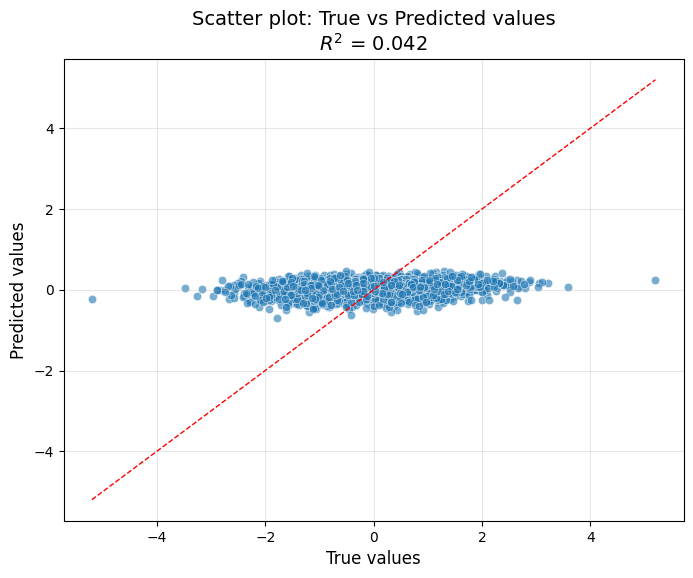

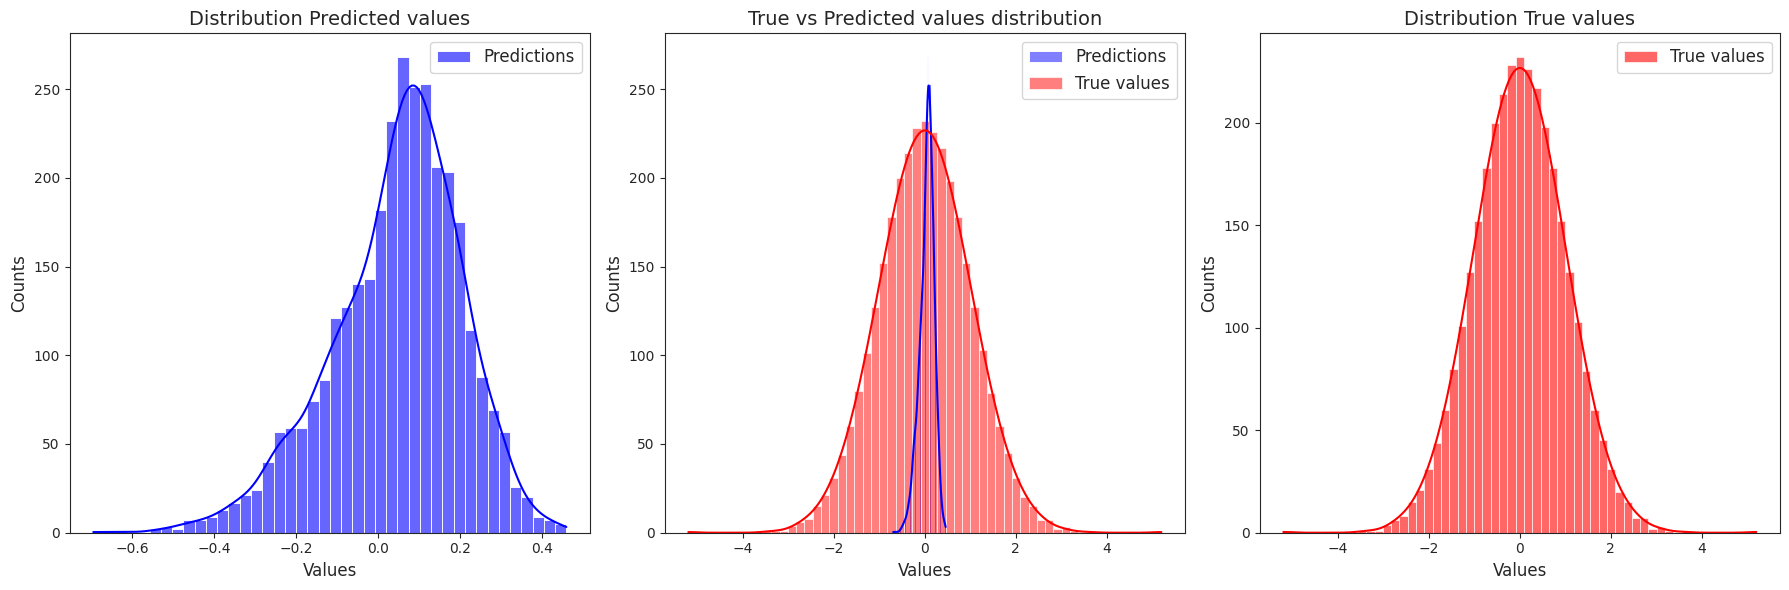

Testing DataLoader 0: 100%|██████████| 25/25 [00:16<00:00,  1.47it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  explained_variance/test  │   0.044210076332092285    │
│         mae/test          │    0.7835220098495483     │
│         mse/test          │    0.9697042107582092     │
│       pearson/test        │    0.21877427399158478    │
│          r2/test          │    0.0422673225402832     │
│         rmse/test         │    0.9847356081008911     │
│       spearman/test       │    0.20742712914943695    │
└───────────────────────────┴───────────────────────────┘

[{'explained_variance/test': 0.044210076332092285,
  'mae/test': 0.7835220098495483,
  'mse/test': 0.9697042107582092,
  'pearson/test': 0.21877427399158478,
  'r2/test': 0.0422673225402832,
  'rmse/test': 0.9847356081008911,
  'spearman/test': 0.20742712914943695}]

In [41]:
trainer.test(
    model=pipeline,
    dataloaders=test_loader,
)

Разморозка всей модели

In [77]:
checkpoint_path = '/home/jupyter/datasphere/project/Classification/Classification/1/logs/1/version_1/checkpoints/best.ckpt'
pipeline = Pipeline.load_from_checkpoint(checkpoint_path, model=CustomBertRegression(model, aggregation_strategy="mean_pooling"))
model_for_finetuning = pipeline.model
model_for_finetuning

CustomBertRegression(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(620, 768, padding_idx=0)
      (position_embeddings): Embedding(551, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-3): 4 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementw

In [78]:
for param in model_for_finetuning.parameters():
    param.requires_grad = True

In [79]:
for name, param in model_for_finetuning.named_parameters():
    print(name, "\t", param.requires_grad)

bert.embeddings.word_embeddings.weight 	 True
bert.embeddings.position_embeddings.weight 	 True
bert.embeddings.token_type_embeddings.weight 	 True
bert.embeddings.LayerNorm.weight 	 True
bert.embeddings.LayerNorm.bias 	 True
bert.encoder.layer.0.attention.self.query.weight 	 True
bert.encoder.layer.0.attention.self.query.bias 	 True
bert.encoder.layer.0.attention.self.key.weight 	 True
bert.encoder.layer.0.attention.self.key.bias 	 True
bert.encoder.layer.0.attention.self.value.weight 	 True
bert.encoder.layer.0.attention.self.value.bias 	 True
bert.encoder.layer.0.attention.output.dense.weight 	 True
bert.encoder.layer.0.attention.output.dense.bias 	 True
bert.encoder.layer.0.attention.output.LayerNorm.weight 	 True
bert.encoder.layer.0.attention.output.LayerNorm.bias 	 True
bert.encoder.layer.0.intermediate.dense.weight 	 True
bert.encoder.layer.0.intermediate.dense.bias 	 True
bert.encoder.layer.0.output.dense.weight 	 True
bert.encoder.layer.0.output.dense.bias 	 True
bert.encoder

In [80]:
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from lightning.pytorch import Trainer
from lightning.pytorch.loggers import TensorBoardLogger

tokenizer = fast_tokenizer

#model_for_finetuning.train()
exp_name = f'{model_n_to_save + "finetuned"}'
logger = TensorBoardLogger(save_dir=path_dir_models + model_n_to_save + '/logs/', name=exp_name)

pipeline = Pipeline(
    model=model_for_finetuning,
    exp_name=exp_name,
    optimizer_class=AdamW,
    optimizer_kwargs={"lr": learning_rate, "weight_decay": 0.1},
    n_classes=5,
)

checkpoint_callback = ModelCheckpoint(
    monitor="Loss/val", mode="min", filename="best"
)

trainer = Trainer(
        max_epochs=epochs,
        callbacks=[checkpoint_callback],
        log_every_n_steps=10,
        logger=logger,
    )

trainer.fit(
    model=pipeline,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

Epoch 17: 100%|██████████| 116/116 [03:17<00:00,  0.59it/s, v_num=0, Loss/train=1.610, Loss/val=1.610, val_accuracy=0.199, val_f1_macro=0.0665]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 18: 100%|██████████| 116/116 [03:17<00:00,  0.59it/s, v_num=0, Loss/train=1.610, Loss/val=1.610, val_accuracy=0.199, val_f1_macro=0.0665]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 19: 100%|██████████| 116/116 [03:17<00:00,  0.59it/s, v_num=0, Loss/train=1.610, Loss/val=1.610, val_accuracy=0.199, val_f1_macro=0.0665]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 19: 100%|██████████| 116/116 [03:33<00:00,  0.54it/s, v_num=0, Loss/train=1.610, Loss/val=1.610, val_accuracy=0.199, val_f1_macro=0.0665]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 116/116 [03:33<00:00,  0.54it/s, v_num=0, Loss/train=1.610, Loss/val=1.610, val_accuracy=0.199, val_f1_macro=0.0665]


In [85]:
model = pipeline.model

In [83]:
pipeline = Pipeline(
    model=model_for_finetuning,
    exp_name=exp_name,
    optimizer_class=AdamW,
    optimizer_kwargs={"lr": learning_rate, "weight_decay": 0.1},
    n_classes=5,
)
trainer.test(
    model=pipeline,
    dataloaders=test_loader,
)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0:   0%|          | 0/25 [02:53<?, ?it/s]


AttributeError: 'Pipeline' object has no attribute 'test_true_values'

In [ ]:
checkpoint_path = '/home/jupyter/datasphere/project/BERT project/Models Regression/5/logs/5finetuned/version_0/checkpoints/best.ckpt'
pipeline = Pipeline.load_from_checkpoint(checkpoint_path, model=CustomBertRegression(model, aggregation_strategy="mean_pooling"))
model_for_finetuning_test = pipeline.model
model_for_finetuning_

In [38]:
trainer.test(
    model=pipeline,
    dataloaders=test_loader,
)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 25/25 [00:15<00:00,  1.59it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  explained_variance/test  │   -0.08481419086456299    │
│         mae/test          │    0.7054395079612732     │
│         mse/test          │    0.8368474841117859     │
│       pearson/test        │    0.20949707925319672    │
│          r2/test          │   -0.09396219253540039    │
│         rmse/test         │    0.9147936701774597     │
│       spearman/test       │    0.20067308843135834    │
└───────────────────────────┴───────────────────────────┘

[{'explained_variance/test': -0.08481419086456299,
  'mae/test': 0.7054395079612732,
  'mse/test': 0.8368474841117859,
  'pearson/test': 0.20949707925319672,
  'r2/test': -0.09396219253540039,
  'rmse/test': 0.9147936701774597,
  'spearman/test': 0.20067308843135834}]

Датасет

In [19]:
path = '/home/jupyter/datasphere/project/BERT project/'

In [20]:
data = pd.read_csv(path + 'PRIME_Dataset.csv')

In [21]:
texts = data['motif_id'].map(eval)

In [22]:
df = pd.DataFrame(texts)
df['len'] = df['motif_id'].str.len()
df['motif_id'] = df['motif_id'].map(' '.join)
df

,motif_id,len
0,AT3G22760 AT1G51140 AT2G42280 AT1G35460 AT1G51...,367
1,AT3G57920 AT3G61120 AT2G45650 AT4G18960 AT2G38...,411
2,AT4G30080 AT4G35550 AT4G38000 AT4G01280 AT1G49...,425
3,AT5G13790 AT5G10140 AT5G15800 AT4G18960 AT3G54...,352
4,AT3G46070 AT1G51600 AT2G38090 AT2G38090 AT4G38...,249
...,...,...
21180,AT1G70000 AT1G74840 AT5G08520 AT5G03150 AT5G67...,266
21181,AT3G30210 AT1G13450 AT1G02065 AT4G14770 AT3G24...,367
21182,AT3G25990 AT1G32510 AT5G18090 AT2G38090 AT1G18...,428
21183,AT2G22430 AT2G18350 AT1G69180 AT4G37790 AT3G24...,412


In [23]:
from sklearn.preprocessing import QuantileTransformer

# Пример данных с выбросами


# Инициализация трансформера
transformer = QuantileTransformer(
    output_distribution='normal',
    n_quantiles=1000,
    random_state=42
)

# Применение преобразования
y_qt = transformer.fit_transform(data['log_mean'].values.reshape(-1, 1)).flatten()

In [24]:
num_classes = 5
labels = [i for i in range(num_classes)]
bins = pd.qcut(y_qt, q=num_classes, labels=labels)

In [25]:
x_train, x, y_train, y = train_test_split(df['motif_id'], bins,
                                          train_size=0.7, shuffle=True,
                                          random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x, y,
                                                train_size=0.5, shuffle=True,
                                                random_state=42)

<Axes: ylabel='Count'>

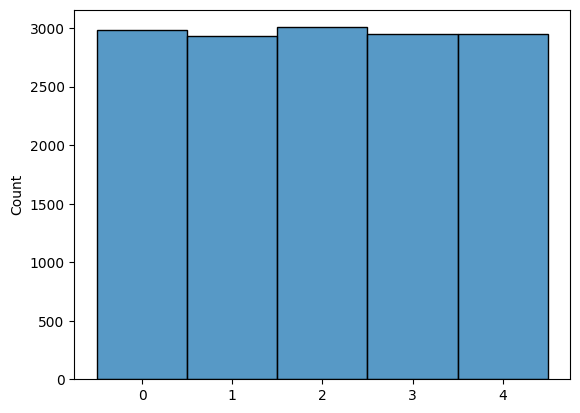

In [26]:
sns.histplot(y_train)

<Axes: xlabel='log_mean'>

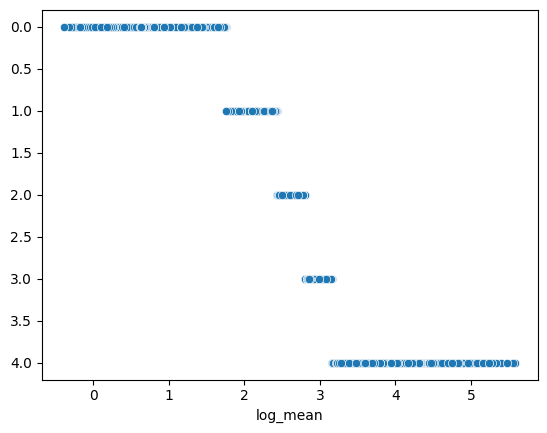

In [63]:
sns.scatterplot(x=data['log_mean'], y=bins)

In [27]:
fast_tokenizer = PreTrainedTokenizerFast(
    tokenizer_file=path + "my_tokenizer.json",
    pad_token="[PAD]",
    unk_token="[UNK]",
    cls_token="[CLS]",
    sep_token="[SEP]",
    mask_token="[MASK]"
)

In [28]:
train_in = fast_tokenizer(x_train.tolist(), padding=True, truncation=True, max_length=551, return_tensors="pt")
val_in = fast_tokenizer(x_val.tolist(), padding=True, truncation=True, max_length=551, return_tensors="pt")
test_in = fast_tokenizer(x_test.tolist(), padding=True, truncation=True, max_length=551, return_tensors="pt")

In [29]:
from torch.utils.data import DataLoader, TensorDataset

train_ds = TensorDataset(
    train_in['input_ids'],
    train_in['attention_mask'],
    torch.LongTensor(y_train)
)
val_ds = TensorDataset(
    val_in['input_ids'],
    val_in['attention_mask'],
    torch.LongTensor(y_val)
)
test_ds = TensorDataset(
    test_in['input_ids'],
    test_in['attention_mask'],
    torch.LongTensor(y_test)
)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=128, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=128, num_workers=4)

In [67]:
next(iter(train_loader))

[tensor([[  2, 591, 591,  ...,   0,   0,   0],
         [  2, 217, 370,  ...,   0,   0,   0],
         [  2, 598, 593,  ...,   0,   0,   0],
         ...,
         [  2, 113, 506,  ...,   0,   0,   0],
         [  2,  59, 396,  ..., 531, 531,   3],
         [  2, 351,  12,  ...,   0,   0,   0]]),
 tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 0, 0, 0]]),
 tensor([4, 0, 2, 2, 1, 1, 4, 2, 3, 3, 3, 3, 2, 1, 4, 3, 1, 1, 3, 0, 0, 3, 0, 2,
         1, 4, 3, 4, 1, 3, 4, 3, 2, 4, 3, 1, 2, 0, 1, 4, 0, 4, 0, 1, 4, 2, 1, 1,
         3, 1, 4, 4, 3, 3, 4, 1, 0, 2, 4, 1, 0, 0, 3, 2, 3, 2, 2, 3, 2, 1, 3, 2,
         1, 0, 3, 3, 0, 3, 4, 3, 4, 2, 2, 3, 2, 2, 4, 3, 0, 1, 0, 4, 1, 4, 3, 1,
         3, 4, 2, 4, 1, 1, 3, 1, 0, 4, 0, 1, 2, 4, 1, 4, 4, 3, 0, 3, 3, 2, 4, 2,
         0, 2, 0, 4, 4, 1, 0, 3])]